<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/02_regularization_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Notebook 02 — Regularization Techniques in PyTorch

## Overview
This notebook mirrors Notebook 01 exactly — same techniques, same A/B testing approach, same dataset — but implemented entirely in **PyTorch**. Reading both side-by-side is a great way to understand the API differences between the two frameworks.

**Techniques demonstrated:**
- L1 regularization (manual penalty term)
- L2 regularization (`weight_decay` in the optimizer)
- Dropout (`nn.Dropout`)
- Early stopping (manual validation monitoring)
- All techniques combined

**Key PyTorch vs Keras difference:** Keras bakes L1/L2 into the layer via `kernel_regularizer`. PyTorch has no built-in layer regularizer — instead, L2 is handled by the optimizer's `weight_decay` parameter, and L1 requires you to manually add a penalty term to the loss.

**Dataset:** Fashion-MNIST (10-class clothing classification)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

PyTorch version: 2.10.0+cu128
Device: cuda


## 1. Load & Prepare Fashion-MNIST

We use `torchvision` to download the dataset, then convert to tensors for use with `DataLoader`.

In [2]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),           # converts PIL image to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))  # normalise to [-1, 1]
])

# Download train + test splits
train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split training into train + validation (55000 / 5000)
train_size = 55000
valid_size = 5000
train_set, valid_set = torch.utils.data.random_split(
    train_full, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Train: {len(train_set):,} samples')
print(f'Valid: {len(valid_set):,} samples')
print(f'Test:  {len(test_set):,} samples')

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]

Train: 55,000 samples
Valid: 5,000 samples
Test:  10,000 samples


## 2. Helper Functions

We define reusable `train_epoch` and `evaluate` functions. Then a `train_and_compare` wrapper runs two models and plots their learning curves — the core A/B testing mechanism.

One key PyTorch pattern: you must call `model.train()` before the training loop and `model.eval()` before validation. This controls whether dropout and batch norm behave in training or inference mode.

In [7]:
def compute_l1_penalty(model, lambda_l1):
    """Manually compute L1 penalty across all weight tensors.
    In PyTorch, L1 is not built into any optimizer — we add it to the loss ourselves.
    """
    l1_penalty = torch.tensor(0.0, device=device)
    for name, param in model.named_parameters():
        if 'weight' in name:   # only penalise weights, not biases
            l1_penalty += param.abs().sum()
    return lambda_l1 * l1_penalty


def train_epoch(model, loader, criterion, optimizer, lambda_l1=0.0):
    """Run one full training epoch. Returns (avg_loss, accuracy)."""
    model.train()   # <- activates dropout, batch norm training behaviour
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()                  # clear gradients from previous step

        # Flatten images: (B, 1, 28, 28) -> (B, 784)
        X_flat = X_batch.view(X_batch.size(0), -1)
        outputs = model(X_flat)                # forward pass

        loss = criterion(outputs, y_batch)     # classification loss

        # Add L1 penalty if requested (L2 is handled by weight_decay in the optimizer)
        if lambda_l1 > 0:
            loss = loss + compute_l1_penalty(model, lambda_l1)

        loss.backward()                        # compute gradients
        optimizer.step()                       # update weights

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total


@torch.no_grad()   # disables gradient tracking for speed and memory
def evaluate(model, loader, criterion):
    """Evaluate model on a data loader. Returns (avg_loss, accuracy)."""
    model.eval()   # <- deactivates dropout, uses running stats in batch norm
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_flat = X_batch.view(X_batch.size(0), -1)
        outputs = model(X_flat)
        loss = criterion(outputs, y_batch)

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total


def train_and_compare(model_a, model_b, opt_a, opt_b,
                      label_a='Baseline', label_b='Regularized',
                      epochs=25, lambda_l1_b=0.0, early_stop_patience=0):
    """
    Train two models and plot their learning curves side-by-side (A/B test).
    early_stop_patience: if > 0, applies early stopping to model_b.
    """
    criterion = nn.CrossEntropyLoss()
    hist = {k: [] for k in ['a_tl','a_vl','a_ta','a_va','b_tl','b_vl','b_ta','b_va']}

    best_val_loss_b = float('inf')
    patience_counter = 0
    best_state_b = None
    stopped_at = epochs

    for epoch in range(epochs):
        # --- Model A ---
        tl_a, ta_a = train_epoch(model_a, train_loader, criterion, opt_a)
        vl_a, va_a = evaluate(model_a, valid_loader, criterion)

        # --- Model B ---
        tl_b, ta_b = train_epoch(model_b, train_loader, criterion, opt_b, lambda_l1=lambda_l1_b)
        vl_b, va_b = evaluate(model_b, valid_loader, criterion)

        for k, v in zip(['a_tl','a_vl','a_ta','a_va','b_tl','b_vl','b_ta','b_va'],
                        [tl_a, vl_a, ta_a, va_a, tl_b, vl_b, ta_b, va_b]):
            hist[k].append(v)

        # Early stopping logic for model B
        if early_stop_patience > 0:
            if vl_b < best_val_loss_b:
                best_val_loss_b = vl_b
                patience_counter = 0
                best_state_b = {k: v.clone() for k, v in model_b.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    stopped_at = epoch + 1
                    print(f'Early stopping triggered at epoch {stopped_at}')
                    model_b.load_state_dict(best_state_b)  # restore best weights
                    break

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | '
                  f'{label_a}: val_acc={va_a:.4f} | '
                  f'{label_b}: val_acc={va_b:.4f}')

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ep = range(1, len(hist['a_tl']) + 1)
    ep_b = range(1, len(hist['b_tl']) + 1)

    for ax, t_key, v_key, title in [
        (axes[0], 'a_tl', 'a_vl', 'Loss'),
        (axes[1], 'a_ta', 'a_va', 'Accuracy')
    ]:
        ax.plot(ep, hist[t_key], '--', color='steelblue', label=f'{label_a} train')
        ax.plot(ep, hist[v_key], color='steelblue', label=f'{label_a} val')

    # Separate loop for model B since it may have stopped early
    axes[0].plot(ep_b, hist['b_tl'], '--', color='tomato', label=f'{label_b} train')
    axes[0].plot(ep_b, hist['b_vl'],       color='tomato', label=f'{label_b} val')
    axes[1].plot(ep_b, hist['b_ta'], '--', color='tomato', label=f'{label_b} train')
    axes[1].plot(ep_b, hist['b_va'],       color='tomato', label=f'{label_b} val')

    for ax, title in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    if early_stop_patience > 0 and stopped_at < epochs:
        axes[0].axvline(stopped_at, color='tomato', linestyle=':', alpha=0.7, label='early stop')
        axes[1].axvline(stopped_at, color='tomato', linestyle=':', alpha=0.7)

    plt.suptitle(f'A/B Test: {label_a} vs {label_b}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'\n{label_a} best val accuracy:  {max(hist["a_va"]):.4f}')
    print(f'{label_b} best val accuracy: {max(hist["b_va"]):.4f}')

print('Helper functions ready.')

Helper functions ready.


## 3. Define Model Builders

In PyTorch we define models as classes inheriting `nn.Module`. We write several factory functions for clean A/B test setup.

In [4]:
class BaselineNet(nn.Module):
    """
    A simple fully-connected network with no regularization.
    Intentionally over-parameterized so it overfits clearly.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 300),
            nn.ReLU(),
            nn.Linear(300, 200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 10),
        )

    def forward(self, x):
        return self.net(x)


class DropoutNet(nn.Module):
    """
    Same architecture with nn.Dropout layers inserted after each hidden layer.
    PyTorch's nn.Dropout automatically deactivates during model.eval().
    """
    def __init__(self, rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 300),
            nn.ReLU(),
            nn.Dropout(rate),    # zeros ~30% of activations randomly during training
            nn.Linear(300, 200),
            nn.ReLU(),
            nn.Dropout(rate),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Dropout(rate * 0.7),  # slightly lower rate near output
            nn.Linear(100, 10),
        )

    def forward(self, x):
        return self.net(x)


class CombinedNet(nn.Module):
    """L2 (via weight_decay) + Dropout combined."""
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 300),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(300, 200),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, 10),
        )

    def forward(self, x):
        return self.net(x)


def make_optimizer(model, lr=1e-3, weight_decay=0.0):
    """
    Create an Adam optimizer.
    weight_decay here is L2 regularization — PyTorch applies it internally
    as: effective_loss = loss + weight_decay * sum(w^2)
    This is equivalent to Keras's kernel_regularizer=l2(weight_decay).
    """
    return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


print('Model classes defined.')
# Quick sanity check
dummy = BaselineNet().to(device)
dummy_out = dummy(torch.zeros(4, 784).to(device))
print(f'Baseline output shape: {dummy_out.shape}  (expect: [4, 10])')

Model classes defined.
Baseline output shape: torch.Size([4, 10])  (expect: [4, 10])


## 4. A/B Test: L2 Regularization

### PyTorch approach for L2
In Keras: `Dense(300, kernel_regularizer=l2(0.01))`  
In PyTorch: `Adam(model.parameters(), weight_decay=0.01)`

The optimizer adds `weight_decay * param` to every gradient during the update step — mathematically equivalent to adding `λ * Σw²` to the loss. The advantage is that you configure it once in the optimizer rather than per-layer.

=== A/B Test: No Regularization vs L2 (weight_decay) ===
Epoch  5/25 | No Reg: val_acc=0.8680 | L2 (weight_decay=0.01): val_acc=0.8096
Epoch 10/25 | No Reg: val_acc=0.8884 | L2 (weight_decay=0.01): val_acc=0.8290
Epoch 15/25 | No Reg: val_acc=0.8768 | L2 (weight_decay=0.01): val_acc=0.8278
Epoch 20/25 | No Reg: val_acc=0.8916 | L2 (weight_decay=0.01): val_acc=0.8434
Epoch 25/25 | No Reg: val_acc=0.8936 | L2 (weight_decay=0.01): val_acc=0.8334


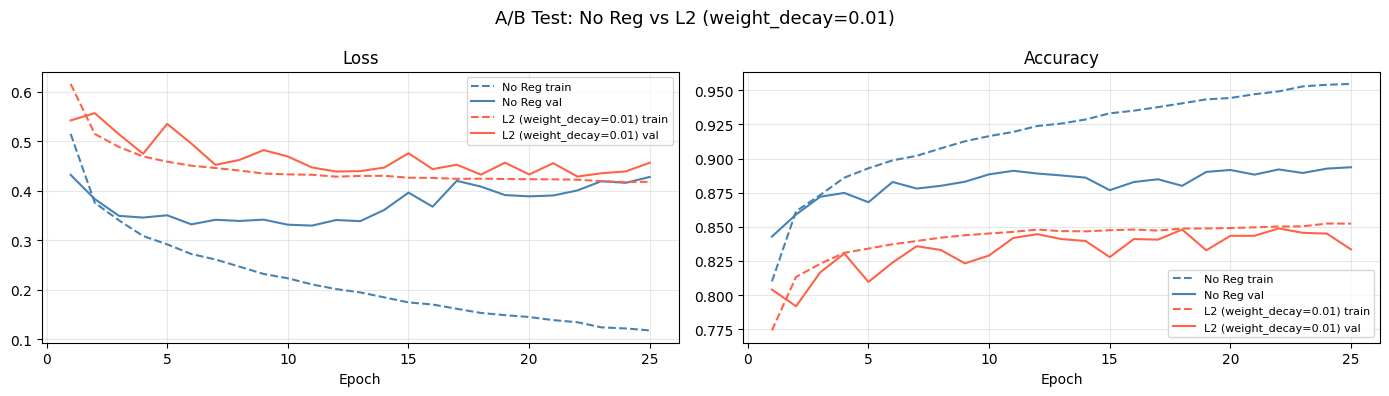


No Reg best val accuracy:  0.8936
L2 (weight_decay=0.01) best val accuracy: 0.8488


In [8]:
print('=== A/B Test: No Regularization vs L2 (weight_decay) ===')

model_baseline = BaselineNet().to(device)
model_l2       = BaselineNet().to(device)   # same architecture

opt_baseline = make_optimizer(model_baseline, lr=1e-3, weight_decay=0.0)
opt_l2       = make_optimizer(model_l2,       lr=1e-3, weight_decay=0.01)  # L2 here

train_and_compare(
    model_baseline, model_l2,
    opt_baseline, opt_l2,
    label_a='No Reg',
    label_b='L2 (weight_decay=0.01)',
    epochs=25
)

## 5. A/B Test: L1 Regularization

### PyTorch approach for L1
L1 has no built-in optimizer support in PyTorch. We add it manually:

```python
loss = criterion(outputs, labels)
for param in model.parameters():
    loss += lambda_l1 * param.abs().sum()
loss.backward()
```

Our `train_epoch` function already handles this via the `lambda_l1` argument and `compute_l1_penalty()`.

=== A/B Test: No Regularization vs L1 (manual penalty) ===
Epoch  5/25 | No Reg: val_acc=0.8748 | L1 (λ=0.0001): val_acc=0.8584
Epoch 10/25 | No Reg: val_acc=0.8804 | L1 (λ=0.0001): val_acc=0.8650
Epoch 15/25 | No Reg: val_acc=0.8884 | L1 (λ=0.0001): val_acc=0.8722
Epoch 20/25 | No Reg: val_acc=0.8882 | L1 (λ=0.0001): val_acc=0.8766
Epoch 25/25 | No Reg: val_acc=0.8902 | L1 (λ=0.0001): val_acc=0.8694


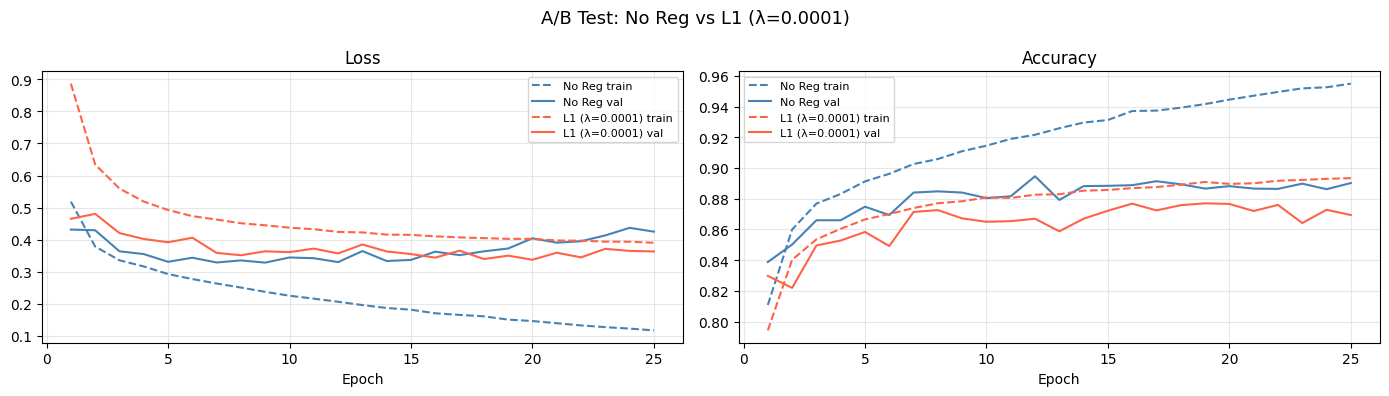


No Reg best val accuracy:  0.8946
L1 (λ=0.0001) best val accuracy: 0.8770


In [9]:
print('=== A/B Test: No Regularization vs L1 (manual penalty) ===')

model_baseline2 = BaselineNet().to(device)
model_l1        = BaselineNet().to(device)

opt_baseline2 = make_optimizer(model_baseline2, lr=1e-3)
opt_l1        = make_optimizer(model_l1,        lr=1e-3)  # no weight_decay — L1 added in loss

train_and_compare(
    model_baseline2, model_l1,
    opt_baseline2, opt_l1,
    label_a='No Reg',
    label_b='L1 (λ=0.0001)',
    epochs=25,
    lambda_l1_b=0.0001   # small λ — L1 is stronger per-unit than L2
)

## 6. A/B Test: Dropout

`nn.Dropout(p)` randomly zeroes elements with probability `p`. Unlike L1/L2, it operates on activations rather than weights. It must be placed after the activation function.

=== A/B Test: No Dropout vs Dropout(0.3) ===
Epoch  5/25 | No Dropout: val_acc=0.8714 | Dropout rate=0.3: val_acc=0.8640
Epoch 10/25 | No Dropout: val_acc=0.8878 | Dropout rate=0.3: val_acc=0.8768
Epoch 15/25 | No Dropout: val_acc=0.8886 | Dropout rate=0.3: val_acc=0.8836
Epoch 20/25 | No Dropout: val_acc=0.8838 | Dropout rate=0.3: val_acc=0.8824
Epoch 25/25 | No Dropout: val_acc=0.8886 | Dropout rate=0.3: val_acc=0.8832


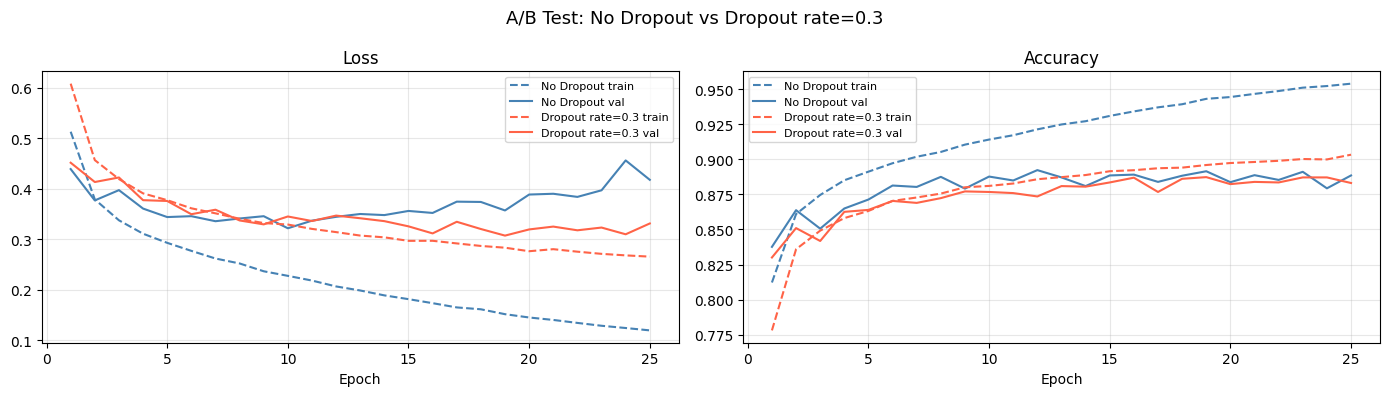


No Dropout best val accuracy:  0.8924
Dropout rate=0.3 best val accuracy: 0.8874


In [10]:
print('=== A/B Test: No Dropout vs Dropout(0.3) ===')

model_no_drop   = BaselineNet().to(device)
model_dropout   = DropoutNet(rate=0.3).to(device)

opt_no_drop  = make_optimizer(model_no_drop,  lr=1e-3)
opt_dropout  = make_optimizer(model_dropout,  lr=1e-3)

train_and_compare(
    model_no_drop, model_dropout,
    opt_no_drop, opt_dropout,
    label_a='No Dropout',
    label_b='Dropout rate=0.3',
    epochs=25
)

## 7. A/B Test: Early Stopping

### PyTorch approach for early stopping
Unlike Keras's `EarlyStopping` callback, PyTorch has no built-in mechanism. We implement it manually:

1. Track best validation loss seen so far
2. If it hasn't improved after `patience` epochs, stop
3. Restore the model weights from the best epoch using `model.state_dict()` / `model.load_state_dict()`

This pattern is already wired into `train_and_compare` via the `early_stop_patience` argument.

=== A/B Test: No Early Stop vs Early Stop (patience=5) ===
Epoch  5/40 | No Early Stop: val_acc=0.8680 | Early Stop (patience=5): val_acc=0.8712
Epoch 10/40 | No Early Stop: val_acc=0.8852 | Early Stop (patience=5): val_acc=0.8758
Epoch 15/40 | No Early Stop: val_acc=0.8798 | Early Stop (patience=5): val_acc=0.8806
Early stopping triggered at epoch 16


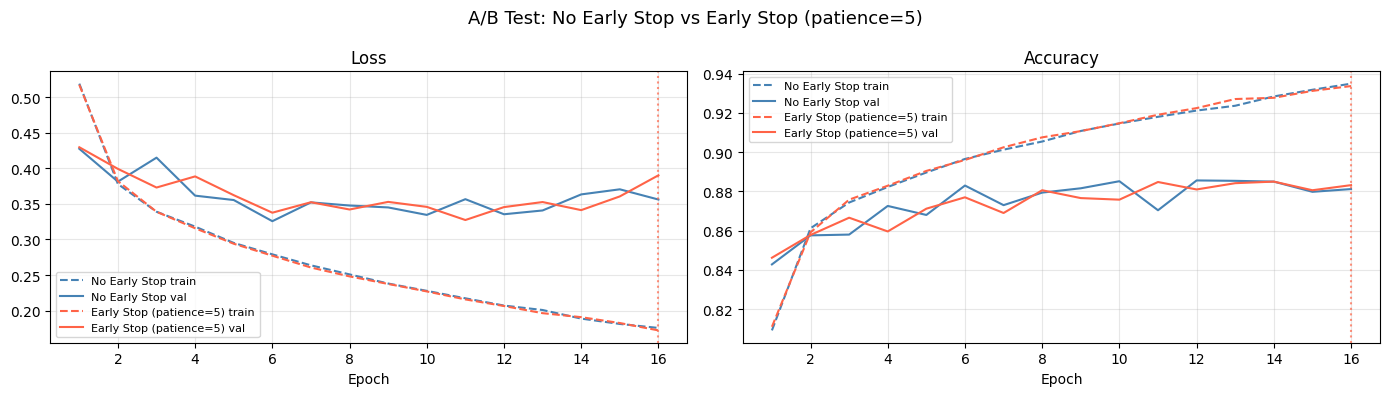


No Early Stop best val accuracy:  0.8856
Early Stop (patience=5) best val accuracy: 0.8850

Note: the vertical dotted line marks where early stopping triggered.


In [11]:
print('=== A/B Test: No Early Stop vs Early Stop (patience=5) ===')

model_no_es = BaselineNet().to(device)
model_es    = BaselineNet().to(device)

opt_no_es = make_optimizer(model_no_es, lr=1e-3)
opt_es    = make_optimizer(model_es,    lr=1e-3)

train_and_compare(
    model_no_es, model_es,
    opt_no_es, opt_es,
    label_a='No Early Stop',
    label_b='Early Stop (patience=5)',
    epochs=40,
    early_stop_patience=5   # stops model_b if val_loss doesn't improve for 5 epochs
)

print('\nNote: the vertical dotted line marks where early stopping triggered.')

## 8. Using a Learning Rate Scheduler

PyTorch provides `torch.optim.lr_scheduler` for LR decay. `ReduceLROnPlateau` halves the LR when validation loss stops improving — analogous to Keras's `ReduceLROnPlateau` callback.

This is a standalone demo (not an A/B test) showing how to integrate a scheduler.

Epoch  5 | val_loss=0.3787 | val_acc=0.8674 | lr=0.001000
Epoch 10 | val_loss=0.3368 | val_acc=0.8814 | lr=0.001000
Epoch 15 | val_loss=0.3259 | val_acc=0.8812 | lr=0.001000
Epoch 20 | val_loss=0.3249 | val_acc=0.8828 | lr=0.000500
Epoch 25 | val_loss=0.3121 | val_acc=0.8868 | lr=0.000500
Epoch 30 | val_loss=0.3025 | val_acc=0.8926 | lr=0.000500


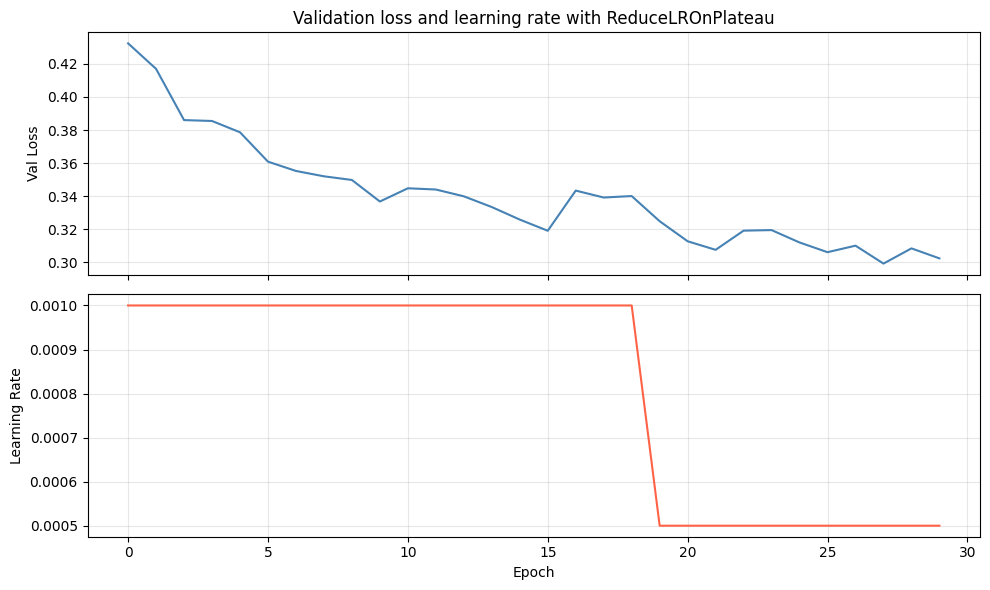

Best val accuracy: 0.8926


In [13]:
model_scheduled = DropoutNet(rate=0.3).to(device)
optimizer_sched = make_optimizer(model_scheduled, lr=1e-3, weight_decay=1e-4)

# Halve LR when val_loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_sched,
    mode='min',       # we are minimising val_loss
    factor=0.5,       # multiply LR by this factor
    patience=3        # wait 3 epochs before reducing
)

criterion = nn.CrossEntropyLoss()
sched_hist = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
EPOCHS = 30

for epoch in range(EPOCHS):
    tl, ta = train_epoch(model_scheduled, train_loader, criterion, optimizer_sched)
    vl, va = evaluate(model_scheduled, valid_loader, criterion)

    scheduler.step(vl)   # pass val_loss to scheduler each epoch

    current_lr = optimizer_sched.param_groups[0]['lr']
    sched_hist['train_loss'].append(tl)
    sched_hist['val_loss'].append(vl)
    sched_hist['val_acc'].append(va)
    sched_hist['lr'].append(current_lr)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:2d} | val_loss={vl:.4f} | val_acc={va:.4f} | lr={current_lr:.6f}')

# Plot LR over time alongside val_loss
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(sched_hist['val_loss'], color='steelblue')
ax1.set_ylabel('Val Loss')
ax1.set_title('Validation loss and learning rate with ReduceLROnPlateau')
ax1.grid(True, alpha=0.3)

ax2.plot(sched_hist['lr'], color='tomato')
ax2.set_ylabel('Learning Rate')
ax2.set_xlabel('Epoch')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best val accuracy: {max(sched_hist["val_acc"]):.4f}')

## 9. All Techniques Combined

The best real-world setup combines multiple techniques. Here we use:
- **L2** via `weight_decay=0.001`
- **Dropout** at rate 0.3
- **Early stopping** with patience=7
- **ReduceLROnPlateau** scheduler

Training combined model (L2 + Dropout + LR Scheduler + Early Stop)...
Epoch  5 | val_loss=0.4168 | val_acc=0.8444
Epoch 10 | val_loss=0.3778 | val_acc=0.8618
Epoch 15 | val_loss=0.3833 | val_acc=0.8584
Epoch 20 | val_loss=0.3502 | val_acc=0.8748
Epoch 25 | val_loss=0.3468 | val_acc=0.8792
Epoch 30 | val_loss=0.3211 | val_acc=0.8832
Epoch 35 | val_loss=0.3205 | val_acc=0.8836
Epoch 40 | val_loss=0.3143 | val_acc=0.8894
Epoch 45 | val_loss=0.3097 | val_acc=0.8890
Epoch 50 | val_loss=0.3143 | val_acc=0.8872


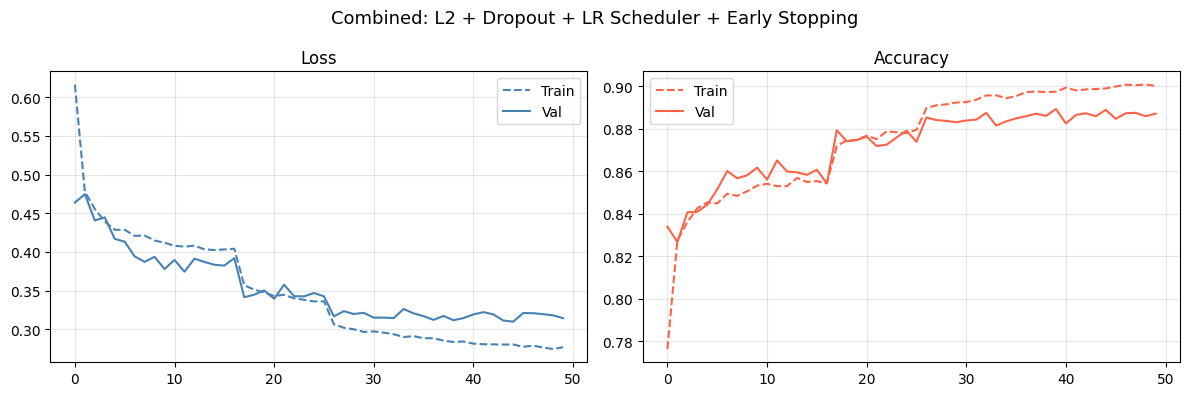


Final test accuracy: 0.8866


In [15]:
model_combined = CombinedNet(dropout_rate=0.3).to(device)
opt_combined   = make_optimizer(model_combined, lr=1e-3, weight_decay=0.001)
sched_combined = optim.lr_scheduler.ReduceLROnPlateau(opt_combined, factor=0.5, patience=4)
criterion      = nn.CrossEntropyLoss()

EPOCHS = 50
PATIENCE = 7
best_val_loss = float('inf')
patience_counter = 0
best_weights = None
combined_hist = {'tl':[], 'vl':[], 'ta':[], 'va':[]}

print('Training combined model (L2 + Dropout + LR Scheduler + Early Stop)...')

for epoch in range(EPOCHS):
    tl, ta = train_epoch(model_combined, train_loader, criterion, opt_combined)
    vl, va = evaluate(model_combined, valid_loader, criterion)
    sched_combined.step(vl)

    for k, v in zip(['tl','vl','ta','va'], [tl, vl, ta, va]):
        combined_hist[k].append(v)

    # Early stopping
    if vl < best_val_loss:
        best_val_loss = vl
        patience_counter = 0
        best_weights = {k: v.clone() for k, v in model_combined.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stop at epoch {epoch+1}')
            model_combined.load_state_dict(best_weights)
            break

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:2d} | val_loss={vl:.4f} | val_acc={va:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(combined_hist['tl'], '--', label='Train', color='steelblue')
axes[0].plot(combined_hist['vl'],       label='Val',   color='steelblue')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(combined_hist['ta'], '--', label='Train', color='tomato')
axes[1].plot(combined_hist['va'],       label='Val',   color='tomato')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Combined: L2 + Dropout + LR Scheduler + Early Stopping', fontsize=13)
plt.tight_layout(); plt.show()

# Final test evaluation
test_loss, test_acc = evaluate(model_combined, test_loader, criterion)
print(f'\nFinal test accuracy: {test_acc:.4f}')

## 10. Saving and Loading a PyTorch Model

PyTorch saves the `state_dict` (weight tensors only) rather than the full model object. This is the recommended approach — it's portable and doesn't depend on your class definition being importable from the same path.

In [16]:
# Save weights only (recommended)
torch.save(model_combined.state_dict(), '/tmp/combined_model.pt')
print('Model state_dict saved to /tmp/combined_model.pt')

# Load: first recreate the architecture, then load weights into it
loaded_model = CombinedNet(dropout_rate=0.3).to(device)
loaded_model.load_state_dict(torch.load('/tmp/combined_model.pt', map_location=device))
loaded_model.eval()
print('Weights loaded successfully.')

# Verify identical outputs
X_sample = next(iter(test_loader))[0][:5].to(device)
X_flat   = X_sample.view(5, -1)

with torch.no_grad():
    original_out = model_combined(X_flat)
    loaded_out   = loaded_model(X_flat)

max_diff = (original_out - loaded_out).abs().max().item()
print(f'Max output difference (should be ~0): {max_diff:.8f}')

Model state_dict saved to /tmp/combined_model.pt
Weights loaded successfully.
Max output difference (should be ~0): 0.00000000


## Summary: PyTorch vs Keras Regularization API

| Technique | Keras | PyTorch |
|---|---|---|
| **L2** | `Dense(..., kernel_regularizer=l2(λ))` | `Adam(..., weight_decay=λ)` |
| **L1** | `Dense(..., kernel_regularizer=l1(λ))` | Manual: add `λ * param.abs().sum()` to loss |
| **Dropout** | `Dropout(rate)` layer | `nn.Dropout(p)` layer |
| **Train/eval mode** | Automatic | Manual: `model.train()` / `model.eval()` |
| **Early stopping** | `EarlyStopping` callback | Manual: track loss, `state_dict()` / `load_state_dict()` |
| **LR schedule** | `ReduceLROnPlateau` callback | `optim.lr_scheduler.ReduceLROnPlateau(optimizer)` |
| **Save model** | `model.save('file.keras')` | `torch.save(model.state_dict(), 'file.pt')` |

**Biggest PyTorch gotcha:** forgetting to call `model.eval()` before validation means dropout stays active and you get noisy, pessimistic validation metrics.

➡️ **Next: Notebook 03** — Monte Carlo Dropout (keep dropout ON at inference time for uncertainty estimation)